# E5 (`e5_pe_sweep`) — Results

Analysis notebook for the E5 PE / architecture sweep (`outputs/e5_pe_sweep/`). All runs train on the e5 graph-oriented dataset and cross-eval on its held-out test graphs.

## Data changes (e5 vs e4)

The e5 dataset (`data/gen/e5_graph_oriented_data/`) keeps e4's skeleton sizing — 5 graph-size configs × 10 seeds = 50 skeletons, 10 tasks each — and changes the task content and generation:

- **Navigation-heavy task mix.** e5 passes `--task-proportions 0.125 0.125 0.15 0.6` → 12.5% Existence, 12.5% Positionality, 15% Reachability, **60% Navigability**. e4 used no `--task-proportions` (default task-type selection). Intent: bias toward multi-hop graph navigation and away from single-node lookups, so PE-based architectures have more to gain.
- **Randomized, seeded task-type sampling** (`GEN_SEED=42`) — reproducible multinomial draw of task types.
- **Cheaper populate.** Graph population uses `gpt-5.1` at reasoning `low` (cost rollback), vs e4's `gpt-5.x` at reasoning `high`.

## Partitions — `e5_train_and_eval.sbatch` (7-task array, `--array=0-6%7`)

All partitions train on the same e5 dataset. The **e4 baseline hparams** are `pe_hidden=256, d_model=1024, L=5, k_pe=3` (GT adds `k_gt=2, gt_num_layers=3, gt_heads=8`) — partitions 5–6 reproduce them exactly as a reference point; partitions 0–4 sweep around them.

Checkpoint dirs are under `outputs/e5_pe_sweep/`. All runs log to wandb entity `alelab`, project `GREP-PRISM`; the 7 sweep partitions carry wandb tag `e5_pe_sweep` (`e5_llm` was logged separately).

| idx | checkpoint dir | wandb run | arch | pe_hidden | d_model | L | k_pe | k_gt | gt_layers | Relative to e4 hparams |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | `e5_cfg1_rpearl_pe4096_dm4096_L5_jad3gxsg` | [`jad3gxsg`](https://wandb.ai/alelab/GREP-PRISM/runs/jad3gxsg) | rpearl | 4096 | 4096 | 5 | 3 | – | – | PE width & d_model → 4096; depth/k unchanged |
| 1 | `e5_cfg2_rpearl_pe4096_dm4096_L2_8yikr0fk` | [`8yikr0fk`](https://wandb.ai/alelab/GREP-PRISM/runs/8yikr0fk) | rpearl | 4096 | 4096 | 2 | 3 | – | – | cfg1 + shallower GNN (L 5→2) |
| 2 | `e5_cfg3_gt_pe4096_dm4096_L2_mvdap4k7` | [`mvdap4k7`](https://wandb.ai/alelab/GREP-PRISM/runs/mvdap4k7) | gt | 4096 | 4096 | 2 | 2 | 2 | 2 | PE & d_model → 4096; L 5→2; k_pe 3→2; gt_num_layers 3→2 |
| 3 | `e5_cfg4_rpearl_pe256_dm4096_L2_rbg6w5c4` | [`rbg6w5c4`](https://wandb.ai/alelab/GREP-PRISM/runs/rbg6w5c4) | rpearl | 256 | 4096 | 2 | 3 | – | – | d_model → 4096 only; PE width stays at e4's 256; L 5→2 |
| 4 | `e5_cfg4_gt_pe256_dm4096_L2_nuohivct` | [`nuohivct`](https://wandb.ai/alelab/GREP-PRISM/runs/nuohivct) | gt | 256 | 4096 | 2 | 2 | 2 | 2 | d_model → 4096; PE width 256; L 5→2; k_pe 3→2; gt_num_layers 3→2 |
| 5 | `e5_e4ref_rpearl_pe256_dm1024_L5_ko2bsa21` | [`ko2bsa21`](https://wandb.ai/alelab/GREP-PRISM/runs/ko2bsa21) | rpearl | 256 | 1024 | 5 | 3 | – | – | **= e4 baseline** (unchanged reference) |
| 6 | `e5_e4ref_gt_pe256_dm1024_L5_8haqdvt5` | [`8haqdvt5`](https://wandb.ai/alelab/GREP-PRISM/runs/8haqdvt5) | gt | 256 | 1024 | 5 | 3 | 2 | 3 | **= e4 baseline** (unchanged reference) |
| 7 | `e5_llm_r5pbg901` | [`r5pbg901`](https://wandb.ai/alelab/GREP-PRISM/runs/r5pbg901) | llm | – | – | – | – | – | – | text-only LLM baseline — graph serialized into the prompt |

`gt_heads = 8` for all GT partitions (yaml default, not swept). Partition 7 (`e5_llm`) is **not part of the `e5_train_and_eval.sbatch` array** — it is a text-only `llm`-architecture baseline (no PE/GNN; the graph is serialized into the prompt) trained separately on the same e5 dataset and added here as the non-graph reference point.

# Results

Checkpoints and held-out test-set logs rsynced from the betty cluster run of
`scripts/e5_train_and_eval.sbatch` into `outputs/e5_pe_sweep/`.

**All 7 sweep partitions are present**, plus a text-only **`llm` baseline**
(`e5_llm`, trained separately — not part of the sbatch array) — **8 runs total**.
The `e4ref` partitions (idx 5–6) reproduce the e4 baseline hparams, so the sweep
is now anchored against the e4 parameter point.

Each run directory holds two kinds of eval log:

- **Cross-eval** — `eval_logs/cross_eval/data_gen_{003,007}.json`, written by
  `scripts/eval_checkpoint_on_graphs.py`. The **final** checkpoint is run over
  the two held-out e5 test graphs, 10 task rollouts each (20 per config).
- **In-training per-epoch eval** — `eval_logs/step_0000{24,48}_epoch_{1,2}.000.json`,
  written by the training callback after each epoch on a *single* held-out
  graph (`data_gen_003`, the first test graph).

Training is 2 epochs, 24 steps/epoch (`checkpoint-24`, `checkpoint-48`).

In [1]:
import json
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

E5_DIR = "../outputs/e5_pe_sweep"

# Shared arch -> colour for every plot in this notebook.
ARCH_COLORS = {"rpearl": "#4c72b0", "gt": "#dd8452", "llm": "#55a868"}

# idx 0-6 mirror the per-task arrays in scripts/e5_train_and_eval.sbatch
# (BASE_YAMLS / PE_HIDDEN / D_MODELS / ...). idx 7 (e5_llm) is a text-only LLM
# baseline trained separately on the same e5 dataset (not part of the array).
CONFIGS = [
    dict(idx=0, label="cfg1",         save_name="e5_cfg1_rpearl_pe4096_dm4096_L5",
         arch="rpearl", pe_hidden=4096, d_model=4096, L=5, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=1, label="cfg2",         save_name="e5_cfg2_rpearl_pe4096_dm4096_L2",
         arch="rpearl", pe_hidden=4096, d_model=4096, L=2, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=2, label="cfg3",         save_name="e5_cfg3_gt_pe4096_dm4096_L2",
         arch="gt",     pe_hidden=4096, d_model=4096, L=2, k_pe=2, k_gt=2, gt_layers=2),
    dict(idx=3, label="cfg4-rpearl",  save_name="e5_cfg4_rpearl_pe256_dm4096_L2",
         arch="rpearl", pe_hidden=256,  d_model=4096, L=2, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=4, label="cfg4-gt",      save_name="e5_cfg4_gt_pe256_dm4096_L2",
         arch="gt",     pe_hidden=256,  d_model=4096, L=2, k_pe=2, k_gt=2, gt_layers=2),
    dict(idx=5, label="e4ref-rpearl", save_name="e5_e4ref_rpearl_pe256_dm1024_L5",
         arch="rpearl", pe_hidden=256,  d_model=1024, L=5, k_pe=3, k_gt=None, gt_layers=None),
    dict(idx=6, label="e4ref-gt",     save_name="e5_e4ref_gt_pe256_dm1024_L5",
         arch="gt",     pe_hidden=256,  d_model=1024, L=5, k_pe=3, k_gt=2, gt_layers=3),
    dict(idx=7, label="llm",          save_name="e5_llm",
         arch="llm",    pe_hidden=None, d_model=None, L=None, k_pe=None, k_gt=None, gt_layers=None),
]

# Resolve each save_name to its checkpoint dir (train_v2 appends "_{wandb_id}").
for c in CONFIGS:
    matches = sorted(d for d in glob.glob(os.path.join(E5_DIR, c["save_name"] + "_*"))
                     if os.path.isdir(d))
    c["ckpt_dir"] = matches[0] if matches else None
    c["run_id"]   = os.path.basename(matches[0]).rsplit("_", 1)[-1] if matches else None

present = [c for c in CONFIGS if c["ckpt_dir"]]
missing = [c for c in CONFIGS if not c["ckpt_dir"]]
print(f"Found {len(present)}/{len(CONFIGS)} runs under {E5_DIR}\n")
for c in present:
    print(f"  [{c['idx']}] {c['label']:13s} {c['arch']:7s} {c['run_id']}  ->  {c['ckpt_dir']}")
for c in missing:
    print(f"  [{c['idx']}] {c['label']:13s} MISSING  (not rsynced / not trained)")

Found 8/8 runs under ../outputs/e5_pe_sweep

  [0] cfg1          rpearl  jad3gxsg  ->  ../outputs/e5_pe_sweep/e5_cfg1_rpearl_pe4096_dm4096_L5_jad3gxsg
  [1] cfg2          rpearl  8yikr0fk  ->  ../outputs/e5_pe_sweep/e5_cfg2_rpearl_pe4096_dm4096_L2_8yikr0fk
  [2] cfg3          gt      mvdap4k7  ->  ../outputs/e5_pe_sweep/e5_cfg3_gt_pe4096_dm4096_L2_mvdap4k7
  [3] cfg4-rpearl   rpearl  rbg6w5c4  ->  ../outputs/e5_pe_sweep/e5_cfg4_rpearl_pe256_dm4096_L2_rbg6w5c4
  [4] cfg4-gt       gt      nuohivct  ->  ../outputs/e5_pe_sweep/e5_cfg4_gt_pe256_dm4096_L2_nuohivct
  [5] e4ref-rpearl  rpearl  ko2bsa21  ->  ../outputs/e5_pe_sweep/e5_e4ref_rpearl_pe256_dm1024_L5_ko2bsa21
  [6] e4ref-gt      gt      8haqdvt5  ->  ../outputs/e5_pe_sweep/e5_e4ref_gt_pe256_dm1024_L5_8haqdvt5
  [7] llm           llm     r5pbg901  ->  ../outputs/e5_pe_sweep/e5_llm_r5pbg901


## Cross-eval — final checkpoint on held-out e5 test graphs

`eval_checkpoint_on_graphs.py` runs the final checkpoint over the two held-out
test graphs (`data_gen_003`, `data_gen_007`), 10 task rollouts each. Each
rollout JSON carries a `correct` bool plus `terminated_by` / `formatted` /
`plan_keyword` diagnostics.

In [2]:
# Per-(config, graph) cross-eval accuracy, and a flat per-rollout sample table.
# NOTE: every cross_eval rollout carries idx=0 (a bug in
# eval_checkpoint_on_graphs.py). The rollouts are emitted in graph task order,
# so the list position is used as task_idx instead.
cross_rows, sample_rows = [], []
for c in present:
    for f in sorted(glob.glob(os.path.join(c["ckpt_dir"], "eval_logs/cross_eval/*.json"))):
        d = json.load(open(f))
        graph = os.path.splitext(os.path.basename(f))[0]
        cross_rows.append(dict(
            label=c["label"], arch=c["arch"], graph=graph,
            num_correct=d["num_correct"], num_samples=d["num_samples"],
            accuracy=d["accuracy"],
        ))
        for pos, s in enumerate(d["samples"]):
            sample_rows.append(dict(
                label=c["label"], arch=c["arch"], graph=graph, task_idx=pos,
                task=s["task"], answer_key=s["answer_key"],
                correct=bool(s["correct"]), formatted=bool(s.get("formatted")),
                plan_keyword=bool(s.get("plan_keyword")),
                terminated_by=s.get("terminated_by"),
            ))

cross_df  = pd.DataFrame(cross_rows)
sample_df = pd.DataFrame(sample_rows)
cross_df.pivot_table(index=["label", "arch"], columns="graph",
                     values="accuracy", sort=False)

,graph,data_gen_003,data_gen_007
label,arch,,
cfg1,rpearl,0.2,0.5
cfg2,rpearl,0.4,0.5
cfg3,gt,0.2,0.4
cfg4-rpearl,rpearl,0.5,0.4
cfg4-gt,gt,0.6,0.4
e4ref-rpearl,rpearl,0.3,0.2
e4ref-gt,gt,0.5,0.7
llm,llm,0.4,0.4


In [3]:
# Pooled cross-eval accuracy per config (both test graphs, 20 rollouts).
summary = (
    sample_df.groupby(["label", "arch"], sort=False)
    .agg(correct=("correct", "sum"), n=("correct", "size"))
    .reset_index()
)
summary["accuracy"] = summary["correct"] / summary["n"]
summary = summary.sort_values("accuracy", ascending=False).reset_index(drop=True)
summary

,label,arch,correct,n,accuracy
0,e4ref-gt,gt,12,20,0.60
1,cfg4-gt,gt,10,20,0.50
2,cfg2,rpearl,9,20,0.45
3,cfg4-rpearl,rpearl,9,20,0.45
4,llm,llm,8,20,0.40
5,cfg1,rpearl,7,20,0.35
6,cfg3,gt,6,20,0.30
7,e4ref-rpearl,rpearl,5,20,0.25


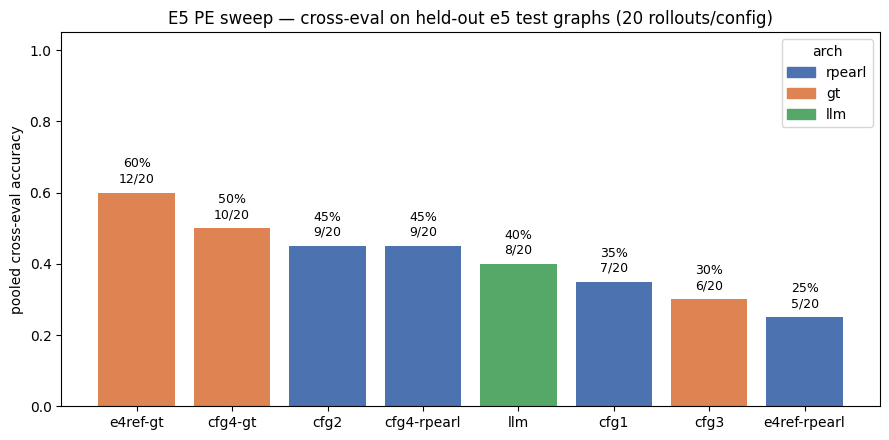

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [ARCH_COLORS.get(a, "#888888") for a in summary["arch"]]
ax.bar(summary["label"], summary["accuracy"], color=colors)
for i, row in summary.iterrows():
    ax.text(i, row["accuracy"] + 0.02, f"{row['accuracy']:.0%}\n{row['correct']}/{row['n']}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("pooled cross-eval accuracy")
ax.set_title("E5 PE sweep \u2014 cross-eval on held-out e5 test graphs (20 rollouts/config)")
archs_seen = [a for a in ["rpearl", "gt", "llm"] if a in summary["arch"].values]
handles = [plt.Rectangle((0, 0), 1, 1, color=ARCH_COLORS[a]) for a in archs_seen]
ax.legend(handles, archs_seen, title="arch")
plt.tight_layout()
plt.show()

The same chart with **Wilson 95% CI error bars** over each config's 20 test
rollouts — the intervals overlap heavily, so the ranking is directional only.

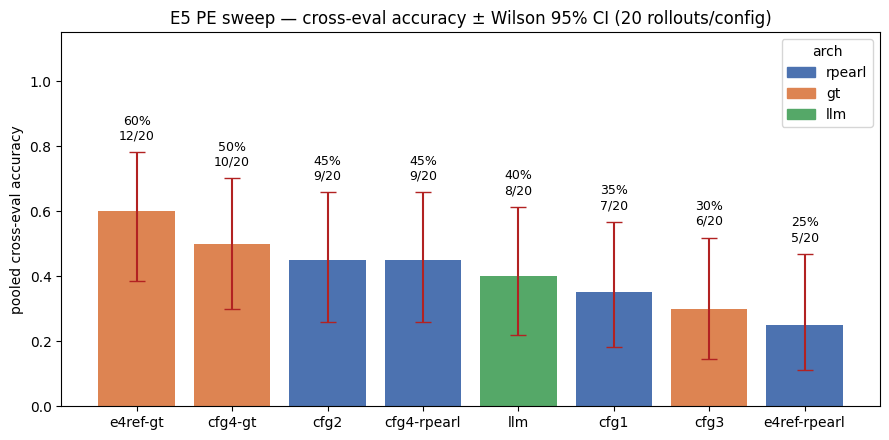

In [5]:
from math import sqrt

def wilson(k, n, z=1.96):
    """Wilson score interval for a binomial proportion -> (point, lo, hi)."""
    if n == 0:
        return np.nan, np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z / denom * sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return p, max(0.0, center - half), min(1.0, center + half)

ci = [wilson(int(r["correct"]), int(r["n"])) for _, r in summary.iterrows()]
lo_err = [p - lo for p, lo, hi in ci]
hi_err = [hi - p for p, lo, hi in ci]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [ARCH_COLORS.get(a, "#888888") for a in summary["arch"]]
ax.bar(summary["label"], summary["accuracy"], color=colors,
       yerr=[lo_err, hi_err], capsize=6,
       error_kw=dict(elinewidth=1.5, ecolor="#b22222"))
for i, (row, he) in enumerate(zip(summary.itertuples(), hi_err)):
    ax.text(i, row.accuracy + he + 0.03, f"{row.accuracy:.0%}\n{row.correct}/{row.n}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("pooled cross-eval accuracy")
ax.set_title("E5 PE sweep \u2014 cross-eval accuracy \u00b1 Wilson 95% CI "
             "(20 rollouts/config)")
archs_seen = [a for a in ["rpearl", "gt", "llm"] if a in summary["arch"].values]
handles = [plt.Rectangle((0, 0), 1, 1, color=ARCH_COLORS[a]) for a in archs_seen]
ax.legend(handles, archs_seen, title="arch")
plt.tight_layout()
plt.show()

### Standard-error error bars

Would it look different with a plain standard-deviation bar instead of the
Wilson CI? Here each bar carries **± 1 standard error** — the normal
approximation `SE = sqrt(p(1-p)/n)`, i.e. the per-sample binary SD
`sqrt(p(1-p))` divided by `sqrt(n)`. (The raw per-sample SD itself is ≈ 0.5 at
these accuracies and is *not* a meaningful error bar on a mean.)

It **is** different from the Wilson version above:

- **Symmetric** — `± SE` is centred on the point estimate; the Wilson interval
  is asymmetric and pulled toward 0.5.
- **Narrower** — `± 1 SE` ≈ ±10 pts here, vs Wilson's ≈ ±20 pts; Wilson 95% is
  closer to `± 1.96 SE`.
- **Unbounded** — the normal approximation can run past 0 or 1 at small `n` or
  extreme `p`; Wilson always stays inside [0, 1]. At `n = 20` it does not
  overflow here, but Wilson is the safer choice for small samples.

The qualitative story is unchanged either way: the per-config gaps sit within
the error bars and the ranking stays directional.

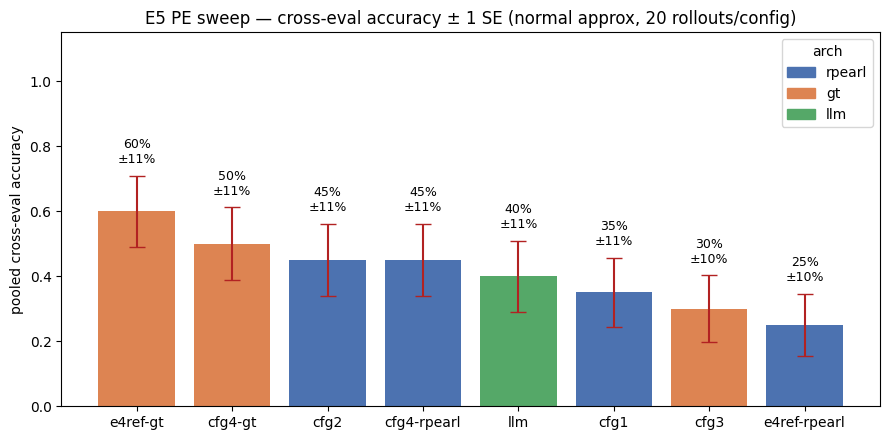

In [6]:
from math import sqrt

# Standard error of the mean accuracy for a binary outcome: sqrt(p(1-p)/n).
sem = [sqrt(p * (1 - p) / n) for p, n in zip(summary["accuracy"], summary["n"])]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [ARCH_COLORS.get(a, "#888888") for a in summary["arch"]]
ax.bar(summary["label"], summary["accuracy"], color=colors,
       yerr=sem, capsize=6, error_kw=dict(elinewidth=1.5, ecolor="#b22222"))
for i, (row, e) in enumerate(zip(summary.itertuples(), sem)):
    ax.text(i, row.accuracy + e + 0.03, f"{row.accuracy:.0%}\n\u00b1{e:.0%}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("pooled cross-eval accuracy")
ax.set_title("E5 PE sweep \u2014 cross-eval accuracy \u00b1 1 SE "
             "(normal approx, 20 rollouts/config)")
archs_seen = [a for a in ["rpearl", "gt", "llm"] if a in summary["arch"].values]
handles = [plt.Rectangle((0, 0), 1, 1, color=ARCH_COLORS[a]) for a in archs_seen]
ax.legend(handles, archs_seen, title="arch")
plt.tight_layout()
plt.show()

## Best config per architecture

The sweep crosses two graph-augmented architectures (`rpearl`, `gt`) plus the
text-only `llm` baseline. The ranking below is *within* each architecture —
which hparam point won for each model type.

In [7]:
# Rank each config within its architecture (ties share a rank).
ranked = summary.copy()
ranked["rank_in_arch"] = (ranked.groupby("arch")["accuracy"]
                          .rank(ascending=False, method="min").astype(int))

# Attach the wandb run id and checkpoint dir for each config.
meta = pd.DataFrame([{"label": c["label"], "wandb_run": c["run_id"],
                      "ckpt_dir": os.path.basename(c["ckpt_dir"])}
                     for c in present])
ranked = ranked.merge(meta, on="label", how="left")
ranked = ranked.sort_values(["arch", "rank_in_arch", "label"]).reset_index(drop=True)

for arch in ["gt", "rpearl", "llm"]:
    sub = ranked[ranked["arch"] == arch]
    if sub.empty:
        continue
    win = sub[sub["rank_in_arch"] == 1]
    names = ", ".join(f"{r.label} ({r.wandb_run})" for r in win.itertuples())
    print(f"{arch:7s} best: {names}  \u2014  {sub['accuracy'].max():.0%}")

ranked[["arch", "rank_in_arch", "label", "accuracy", "correct", "n",
        "wandb_run", "ckpt_dir"]]

gt      best: e4ref-gt (8haqdvt5)  —  60%
rpearl  best: cfg2 (8yikr0fk), cfg4-rpearl (rbg6w5c4)  —  45%
llm     best: llm (r5pbg901)  —  40%


,arch,rank_in_arch,label,accuracy,correct,n,wandb_run,ckpt_dir
0,gt,1,e4ref-gt,0.60,12,20,8haqdvt5,e5_e4ref_gt_pe256_dm1024_L5_8haqdvt5
1,gt,2,cfg4-gt,0.50,10,20,nuohivct,e5_cfg4_gt_pe256_dm4096_L2_nuohivct
2,gt,3,cfg3,0.30,6,20,mvdap4k7,e5_cfg3_gt_pe4096_dm4096_L2_mvdap4k7
3,llm,1,llm,0.40,8,20,r5pbg901,e5_llm_r5pbg901
4,rpearl,1,cfg2,0.45,9,20,8yikr0fk,e5_cfg2_rpearl_pe4096_dm4096_L2_8yikr0fk
5,rpearl,1,cfg4-rpearl,0.45,9,20,rbg6w5c4,e5_cfg4_rpearl_pe256_dm4096_L2_rbg6w5c4
6,rpearl,3,cfg1,0.35,7,20,jad3gxsg,e5_cfg1_rpearl_pe4096_dm4096_L5_jad3gxsg
7,rpearl,4,e4ref-rpearl,0.25,5,20,ko2bsa21,e5_e4ref_rpearl_pe256_dm1024_L5_ko2bsa21


### Observations — best per architecture

- **GT — `e4ref-gt` wins (60%, 12/20).** The e4 baseline GT hparams
  (`pe256 / dm1024 / L5`, `k_pe3`, `gt_layers3`) beat both swept GT configs —
  `cfg4-gt` (50%) and `cfg3` (30%). Pushing PE width and `d_model` to 4096
  while shrinking `L` and `gt_layers` *hurt* GT. GT also has the widest
  within-arch spread (30–60%).
  *wandb `8haqdvt5` · `outputs/e5_pe_sweep/e5_e4ref_gt_pe256_dm1024_L5_8haqdvt5/`*
- **RPEARL — `cfg2` and `cfg4-rpearl` tie (45%, 9/20).** Both shrink the GNN to
  `L=2` and raise `d_model` to 4096, differing only in PE width (cfg2 4096,
  cfg4-rpearl 256) — yet they score **identically, even per task type**
  (Existence 25%, Positionality 67%, Navigability 46%). For RPEARL, PE width is
  inert here. `cfg1` (deep `L=5` GNN, 35%) trails, and the e4 baseline
  `e4ref-rpearl` is the **worst run overall** (25%) — so, unlike GT, the swept
  RPEARL configs beat the e4 point.
  *wandb `8yikr0fk` · `outputs/e5_pe_sweep/e5_cfg2_rpearl_pe4096_dm4096_L2_8yikr0fk/`*
  *wandb `rbg6w5c4` · `outputs/e5_pe_sweep/e5_cfg4_rpearl_pe256_dm4096_L2_rbg6w5c4/`*
- **LLM — `e5_llm` (40%, 8/20), single run.** No sweep — the text-only
  baseline. It clears 3 of the 7 graph-augmented configs but trails both GT
  leaders.
  *wandb `r5pbg901` · `outputs/e5_pe_sweep/e5_llm_r5pbg901/`*
- **Across architectures:** GT holds both the top (`e4ref-gt` 60%) and, via
  RPEARL, the bottom (`e4ref-rpearl` 25%) — the e4 baseline is excellent for GT
  and poor for RPEARL. Best GT (60%) > best RPEARL (45%) > LLM (40%). All gaps
  stay within the Wilson 95% CIs, so read this as directional.

(wandb runs: entity `alelab`, project `GREP-PRISM` — `https://wandb.ai/alelab/GREP-PRISM/runs/<id>`.)

In [8]:
# Failure-mode breakdown over incorrect cross-eval rollouts.
bad = sample_df[~sample_df["correct"]]
print(f"{len(bad)}/{len(sample_df)} cross-eval rollouts incorrect\n")
print("terminated_by (all rollouts):")
print(sample_df.groupby("terminated_by").size().to_string())
print(f"\nunformatted response : {(~sample_df['formatted']).sum()}")
print(f"missing plan keyword : {(~sample_df['plan_keyword']).sum()}")

94/160 cross-eval rollouts incorrect

terminated_by (all rollouts):
terminated_by
answer            132
bad_plan           10
max_iterations     18

unformatted response : 10
missing plan keyword : 94


## In-training per-epoch eval

The training callback evals one held-out graph (`data_gen_003`) after each
epoch. Note this is a *different* eval path from the cross-eval above — compare
trends within this table, not absolute numbers against the cross-eval pass.

In [9]:
epoch_rows = []
for c in present:
    for f in sorted(glob.glob(os.path.join(c["ckpt_dir"], "eval_logs/step_*.json"))):
        d = json.load(open(f))
        epoch_rows.append(dict(
            label=c["label"], arch=c["arch"], epoch=int(d["epoch"]), step=d["step"],
            accuracy=d["accuracy"], num_correct=d["num_correct"],
            num_samples=d["num_samples"],
        ))
epoch_df = pd.DataFrame(epoch_rows)
epoch_pivot = epoch_df.pivot_table(index=["label", "arch"], columns="epoch",
                                   values="accuracy", sort=False)
epoch_pivot.columns = [f"epoch_{e}" for e in epoch_pivot.columns]
epoch_pivot

,,epoch_1,epoch_2
label,arch,,
cfg1,rpearl,1.0,0.9
cfg2,rpearl,1.0,1.0
cfg3,gt,0.8,0.9
cfg4-rpearl,rpearl,0.9,0.9
cfg4-gt,gt,0.8,0.9
e4ref-rpearl,rpearl,1.0,0.9
e4ref-gt,gt,1.0,0.9
llm,llm,1.0,1.0


## Training & eval loss curves

From `checkpoint-48/trainer_state.json` (`log_history`) — train loss is logged
every 15 steps, eval loss/token-accuracy every 24 steps (once per epoch).

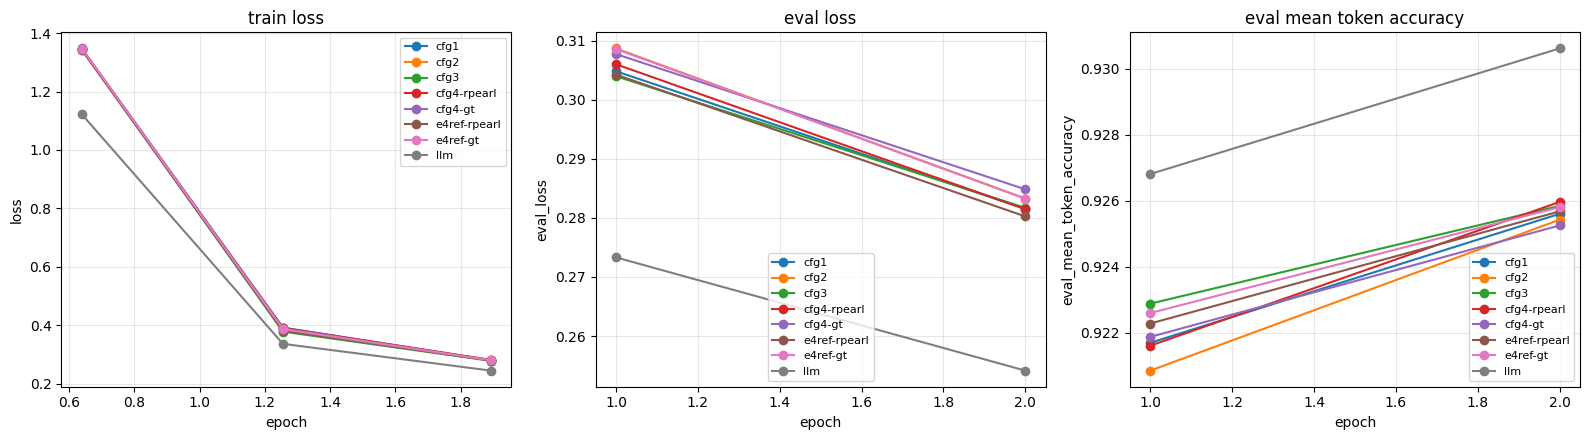

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for c in present:
    ts = os.path.join(c["ckpt_dir"], "checkpoint-48", "trainer_state.json")
    if not os.path.exists(ts):
        continue
    hist = json.load(open(ts))["log_history"]
    tr  = [(h["epoch"], h["loss"])      for h in hist if "loss" in h]
    ev  = [(h["epoch"], h["eval_loss"]) for h in hist if "eval_loss" in h]
    eta = [(h["epoch"], h["eval_mean_token_accuracy"])
           for h in hist if "eval_mean_token_accuracy" in h]
    if tr:
        axes[0].plot(*zip(*tr), marker="o", label=c["label"])
    if ev:
        axes[1].plot(*zip(*ev), marker="o", label=c["label"])
    if eta:
        axes[2].plot(*zip(*eta), marker="o", label=c["label"])
axes[0].set(title="train loss", xlabel="epoch", ylabel="loss")
axes[1].set(title="eval loss", xlabel="epoch", ylabel="eval_loss")
axes[2].set(title="eval mean token accuracy", xlabel="epoch",
            ylabel="eval_mean_token_accuracy")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Per-task-type analysis

The e5 dataset mixes four task types (`prism.data.data_gen.TASK_TAXONOMY`) —
**Existence**, **Positionality**, **Reachability**, **Navigability** — drawn per
graph from the `--task-proportions 0.125 0.125 0.15 0.6` multinomial.

The type label is **not persisted** in the task JSON (`_metadata` is stripped
during generation), so it is reconstructed below with a heuristic classifier
keyed on the answer-regex shape and the task framing:

| inferred type | signature |
|---|---|
| **Navigability**  | route regex — two+ node names joined by `.*` (`\bA\b.*\bB\b`) |
| **Positionality** | regex matches a single node name (a lookup answer) |
| **Existence**     | yes/no regex with existence framing ("is there a …", "any single …") |
| **Reachability**  | yes/no regex with one-hop framing ("move directly …", "in one move") |

The 2 held-out test graphs are shared across all configs, so the classification
is the same set of 20 tasks for every partition — small enough to eyeball in the
audit table below.

In [11]:
import re

TASK_TYPES = ["Existence", "Positionality", "Reachability", "Navigability"]

def classify_task(task_text, answer_regex):
    """Heuristic task-type label (the type is not stored in the task JSON)."""
    nodes = re.findall(r"[a-z][a-z_]*_\d+", answer_regex)   # e.g. freight_corridor_1
    is_yesno = (r"\byes\b" in answer_regex) or (r"\bno\b" in answer_regex)
    if ".*" in answer_regex and len(nodes) >= 2:
        return "Navigability"                  # route: A .* B [.* C]
    if nodes and not is_yesno:
        return "Positionality"                 # single node-name lookup
    t = task_text.lower()
    existence_cues = ["is there a", "is there any", "whether there is",
                      "whether there", "includes any", "stored anywhere",
                      "any single", "exist"]
    reach_cues = ["directly from", "move directly", "in one move", "in one step",
                  "one hop", "direct link", "direct connection",
                  "directly connected to"]
    if any(k in t for k in existence_cues):
        return "Existence"
    if any(k in t for k in reach_cues):
        return "Reachability"
    return "Existence"                         # default for unframed yes/no

sample_df["task_type"] = [
    classify_task(t, a) for t, a in zip(sample_df["task"], sample_df["answer_key"])
]

# Audit table — the 20 tasks of the shared test set, classified.
audit = (sample_df[sample_df["label"] == present[0]["label"]]
         [["graph", "task_idx", "task_type", "task"]].reset_index(drop=True).copy())
audit["task"] = audit["task"].str.slice(0, 78) + "\u2026"
audit

,graph,task_idx,task_type,task
0,data_gen_003,0,Existence,Determine whether there is any single back-of-...
1,data_gen_003,1,Positionality,"From elsewhere in the complex, identify which ..."
2,data_gen_003,2,Navigability,Is there a route from the main public foyer at...
3,data_gen_003,3,Navigability,Can the robot travel from the cafe lounge area...
4,data_gen_003,4,Navigability,Is there a connected route from the storage wa...
5,data_gen_003,5,Positionality,"Starting from the outdoor sculpture lawn, dete..."
6,data_gen_003,6,Navigability,Is there a route from the hedge-lined garden w...
7,data_gen_003,7,Navigability,From the freight corridor deep in the service ...
8,data_gen_003,8,Navigability,Is there a route from the grassy sculpture law...
9,data_gen_003,9,Navigability,"Starting in the main foyer, can the robot reac..."


In [12]:
# Test-set task-type composition (20 tasks) vs the e5 generation target.
target = {"Existence": 0.125, "Positionality": 0.125,
          "Reachability": 0.15, "Navigability": 0.60}
counts = (sample_df[sample_df["label"] == present[0]["label"]]
          ["task_type"].value_counts())
dist = pd.DataFrame({
    "n_tasks":     counts,
    "share":       (counts / counts.sum()).round(3),
    "gen_target":  pd.Series(target),
}).reindex(TASK_TYPES).fillna(0)
dist["n_tasks"] = dist["n_tasks"].astype(int)
dist

,n_tasks,share,gen_target
Existence,4,0.20,0.125
Positionality,3,0.15,0.125
Reachability,0,0.00,0.150
Navigability,13,0.65,0.600


In [13]:
# Cross-eval accuracy split by task type (pooled over both test graphs).
by_type = (sample_df.groupby(["label", "arch", "task_type"], sort=False)
           .agg(correct=("correct", "sum"), n=("correct", "size"))
           .reset_index())
by_type["accuracy"] = by_type["correct"] / by_type["n"]

acc_pivot = by_type.pivot_table(index=["label", "arch"], columns="task_type",
                                values="accuracy", sort=False)
acc_pivot = acc_pivot.reindex(columns=[t for t in TASK_TYPES
                                       if t in acc_pivot.columns])
acc_pivot.round(3)

,task_type,Existence,Positionality,Navigability
label,arch,,,
cfg1,rpearl,0.50,0.333,0.308
cfg2,rpearl,0.25,0.667,0.462
cfg3,gt,0.25,0.333,0.308
cfg4-rpearl,rpearl,0.25,0.667,0.462
cfg4-gt,gt,0.50,0.333,0.538
e4ref-rpearl,rpearl,0.00,0.000,0.385
e4ref-gt,gt,0.75,0.667,0.538
llm,llm,0.00,0.333,0.538


In [14]:
# Pooled across all configs — is any task type systematically harder?
pooled = (sample_df.groupby("task_type", sort=False)
          .agg(accuracy=("correct", "mean"), correct=("correct", "sum"),
               n=("correct", "size")))
pooled = pooled.reindex([t for t in TASK_TYPES if t in pooled.index])
pooled["accuracy"] = pooled["accuracy"].round(3)
pooled

,accuracy,correct,n
task_type,,,
Existence,0.312,10,32
Positionality,0.417,10,24
Navigability,0.442,46,104


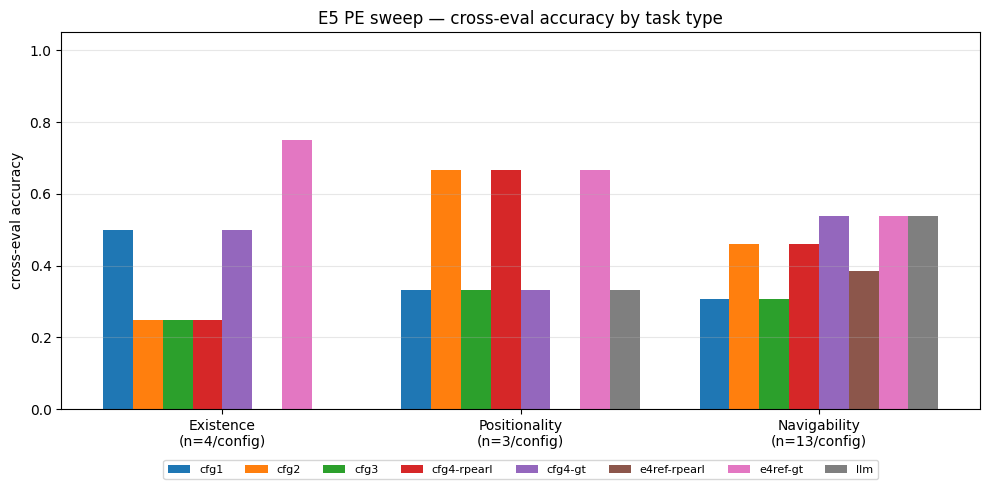

In [15]:
types_present = [t for t in TASK_TYPES if t in by_type["task_type"].values]
labels = [c["label"] for c in present]
counts = sample_df[sample_df["label"] == present[0]["label"]]["task_type"].value_counts()

x = np.arange(len(types_present))
w = 0.8 / len(labels)
fig, ax = plt.subplots(figsize=(10, 5))
for i, lab in enumerate(labels):
    arch = next(c["arch"] for c in present if c["label"] == lab)
    vals = [acc_pivot.loc[(lab, arch), t]
            if (lab, arch) in acc_pivot.index and t in acc_pivot.columns
            else np.nan
            for t in types_present]
    ax.bar(x + i * w, vals, w, label=lab)
ax.set_xticks(x + w * (len(labels) - 1) / 2)
ax.set_xticklabels([f"{t}\n(n={int(counts.get(t, 0))}/config)" for t in types_present])
ax.set_ylim(0, 1.05)
ax.set_ylabel("cross-eval accuracy")
ax.set_title("E5 PE sweep \u2014 cross-eval accuracy by task type")
ax.legend(fontsize=8, ncol=len(labels), loc="upper center",
          bbox_to_anchor=(0.5, -0.12))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Best model — accuracy with error bars across test samples

The best partition by pooled cross-eval accuracy (top row of `summary`). Bars
show accuracy overall and per task type; **error bars are Wilson 95% confidence
intervals** over the binary per-sample outcomes — the right interval for a
proportion at small `n` (it stays inside [0, 1] and is asymmetric near the
edges, unlike a plain ±√(p(1−p)/n) bar). The intervals are wide because each
category has only a handful of test rollouts.

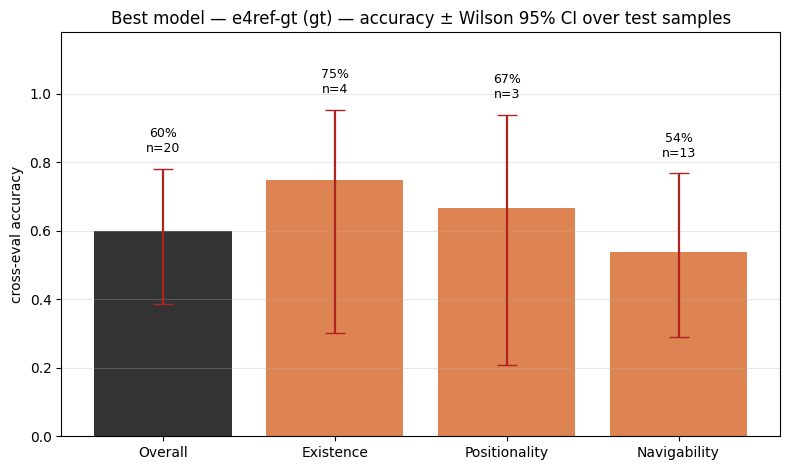

Best model: e4ref-gt (gt)  overall 12/20 = 60%
  Existence      3/4 = 75%  95% CI [30%, 95%]
  Positionality  2/3 = 67%  95% CI [21%, 94%]
  Navigability   7/13 = 54%  95% CI [29%, 77%]


In [16]:
from math import sqrt

def wilson(k, n, z=1.96):
    """Wilson score interval for a binomial proportion -> (point, lo, hi)."""
    if n == 0:
        return np.nan, np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z / denom * sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return p, max(0.0, center - half), min(1.0, center + half)

# Best model = top of the pooled cross-eval summary.
best = summary.iloc[0]
bs = sample_df[sample_df["label"] == best["label"]]

groups = [("Overall", bs)]
groups += [(t, bs[bs["task_type"] == t]) for t in TASK_TYPES
           if (bs["task_type"] == t).any()]

cats, point, lo_err, hi_err, ns = [], [], [], [], []
for name, sub in groups:
    p, lo, hi = wilson(int(sub["correct"].sum()), len(sub))
    cats.append(name)
    point.append(p)
    lo_err.append(p - lo)
    hi_err.append(hi - p)
    ns.append(len(sub))

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = ["#333333"] + [ARCH_COLORS.get(best["arch"], "#888888")] * (len(cats) - 1)
ax.bar(cats, point, color=colors,
       yerr=[lo_err, hi_err], capsize=7,
       error_kw=dict(elinewidth=1.6, ecolor="#b22222"))
for i, (p, he, n) in enumerate(zip(point, hi_err, ns)):
    ax.text(i, p + he + 0.04, f"{p:.0%}\nn={n}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_ylabel("cross-eval accuracy")
ax.set_title(f"Best model \u2014 {best['label']} ({best['arch']}) "
             f"\u2014 accuracy \u00b1 Wilson 95% CI over test samples")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best model: {best['label']} ({best['arch']})  "
      f"overall {int(bs['correct'].sum())}/{len(bs)} = {bs['correct'].mean():.0%}")
for name, sub in groups[1:]:
    p, lo, hi = wilson(int(sub["correct"].sum()), len(sub))
    print(f"  {name:14s} {int(sub['correct'].sum())}/{len(sub)} = {p:.0%}  "
          f"95% CI [{lo:.0%}, {hi:.0%}]")

## Observations

- **All 8 runs present** — the 7 `e5_train_and_eval.sbatch` partitions plus the
  text-only `llm` baseline. The `e4ref` partitions now anchor the sweep to the
  e4 hparam point.
- **The e4 baseline GT hparams win.** `e4ref-gt` (pe256 / dm1024 / L5) tops the
  cross-eval at 60% (12/20) — none of the swept configs that raise
  `pe_hidden`/`d_model` to 4096 beat it. Conversely `e4ref-rpearl` is the
  *worst* run at 25%, so the e4 point is only strong for the GT architecture.
- **GT beats RPEARL at the top; the `llm` baseline (40%, 8/20) lands mid-pack.**
  Best GT 60% (`e4ref-gt`), best RPEARL 45% (`cfg2` / `cfg4-rpearl`). Several
  graph-augmented configs sit at or below the text-only LLM — widening the PE
  is not buying generalization here.
- **Still noisy.** 20 rollouts/config; the 25–60% spread is wide but the
  Wilson CIs overlap heavily (see the best-model plot). Treat the ranking as
  directional, not significant.

### Per task type

- The held-out set is Navigability-dominated — 13 Navigability, 4 Existence,
  3 Positionality, **0 Reachability** tasks per config.
- Pooled over all 8 runs: Existence 31% (10/32), Positionality 42% (10/24),
  Navigability 44% (46/104). Navigability — the type PE should most help — is
  no easier than the rest.
- Per-type config ranking is dominated by noise (Existence 4 tasks/config,
  Positionality 3). The task type is inferred by a heuristic classifier —
  audit the per-task table before trusting the split.

### Caveat

- Cross-eval rollout JSONs all carry `idx=0` (`eval_checkpoint_on_graphs.py`
  does not set a real index). This notebook uses list position instead; worth
  fixing in the eval script.